<a href="https://colab.research.google.com/github/Vijii444/CODECRAFT_FSWD_4/blob/develop/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib opencv-python
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


Saving OIP.webp to OIP.webp


(np.float64(-0.5), np.float64(473.5), np.float64(264.5), np.float64(-0.5))

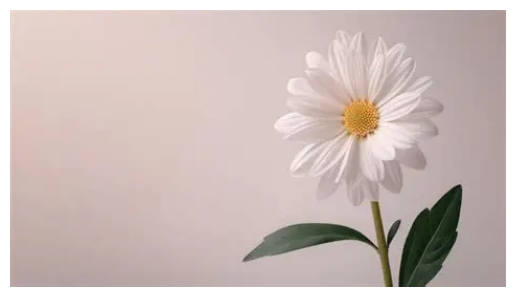

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# upload image from your laptop
uploaded = files.upload()

# use the uploaded filename (must match exactly)
img = cv2.imread("OIP.webp")

if img is None:
    raise ValueError("Image not found. Upload the image correctly.")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(473.5), np.float64(264.5), np.float64(-0.5))

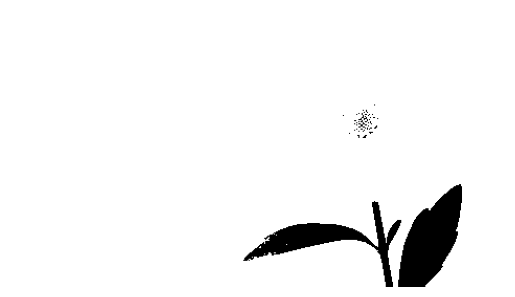

In [ ]:
import numpy as np

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_, mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

plt.imshow(mask, cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(473.5), np.float64(264.5), np.float64(-0.5))

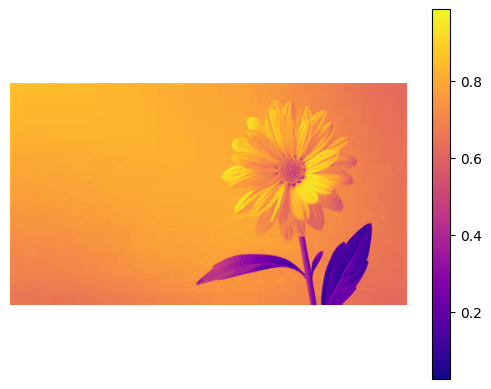

In [ ]:
depth = gray.astype(np.float32) / 255.0

plt.imshow(depth, cmap="plasma")
plt.colorbar()
plt.axis("off")

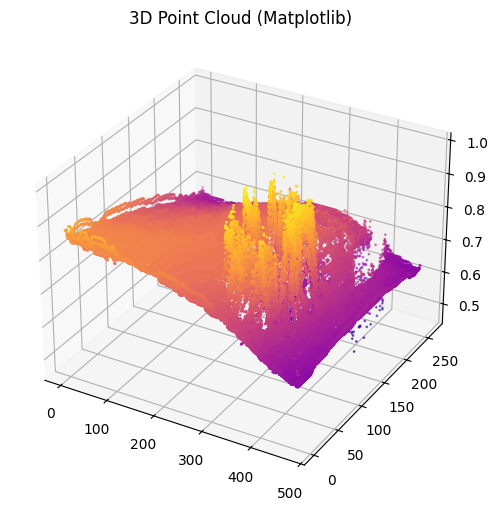

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

h, w = depth.shape
x, y = np.meshgrid(np.arange(w), np.arange(h))

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    x[mask > 0],
    y[mask > 0],
    depth[mask > 0],
    c=depth[mask > 0],
    cmap='plasma',
    s=1
)

ax.set_title("3D Point Cloud (Matplotlib)")
plt.show()

In [ ]:
upload = input("What do you upload? (object/person): ").strip().lower()

url_object = "https://aidemos.meta.com/segment-anything/editor/convert-image-to-3d"
url_person = "https://aidemos.meta.com/segment-anything/editor/convert-body-to-3d"

if upload == "object":
    print("Open this link:", url_object)
elif upload == "person":
    print("Open this link:", url_person)
else:
    print("Invalid input. Please enter 'object' or 'person'.")

What do you upload? (object/person): object
Open this link: https://aidemos.meta.com/segment-anything/editor/convert-image-to-3d


In [ ]:
confidence_score = np.mean(depth[mask > 0])
print(f"Prediction Confidence Score: {confidence_score:.4f}")

Prediction Confidence Score: 0.7541
